# 01 - Dataset Exploration (Brain Tumor Detection)

This notebook aims to explore the structure of the brain tumor MRI image dataset, verify class balance (`yes` / `no`), inspect image dimensions and formats, and visualize sample images.

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from dotenv import load_dotenv

# Display configuration
%matplotlib inline
sns.set_theme(style="whitegrid")
load_dotenv()  

## 1. Path Configuration and Image Counting
> **IMPORTANT:** Modify the `DATA_DIR` variable below if your dataset directory is located elsewhere.

In [ ]:
# Configurable variable for dataset path
DATA_DIR = os.getenv("DATA_DIR")

yes_path = os.path.join(DATA_DIR, "yes")
no_path = os.path.join(DATA_DIR, "no")

# Check if directories exist
if not os.path.exists(yes_path) or not os.path.exists(no_path):
    print(f"⚠️ Warning: The directory '{DATA_DIR}' or its subfolders 'yes'/'no' could not be found. Please check the path.")
else:
    yes_files = os.listdir(yes_path)
    no_files = os.listdir(no_path)
    
    print(f"Number of tumor images (yes): {len(yes_files)}")
    print(f"Number of non-tumor images (no): {len(no_files)}")
    print(f"Total images in the dataset: {len(yes_files) + len(no_files)}")

Number of tumor images (yes): 155
Number of non-tumor images (no): 98
Total images in the dataset: 253


## 2. Class Distribution (Dataset Balance)
Let's visualize the distribution between positive images (tumor detected) and negative images.

C:\Users\ihadi\AppData\Local\Temp\ipykernel_140688\3378941335.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Count', data=df_dist, palette='viridis')


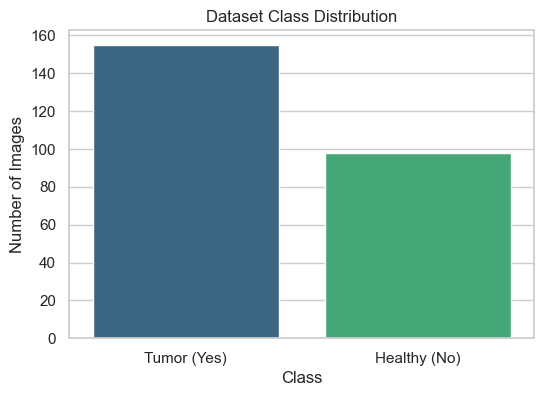

In [10]:
if 'yes_files' in locals() and 'no_files' in locals():
    df_dist = pd.DataFrame({
        'Class': ['Tumor (Yes)', 'Healthy (No)'],
        'Count': [len(yes_files), len(no_files)]
    })

    plt.figure(figsize=(6, 4))
    sns.barplot(x='Class', y='Count', data=df_dist, palette='viridis')
    plt.title("Dataset Class Distribution")
    plt.ylabel("Number of Images")
    plt.show()

## 3. Sample Images Visualization
Randomly display a few samples from each class to visually inspect the MRIs.

Samples from the 'yes' (Tumor) class:


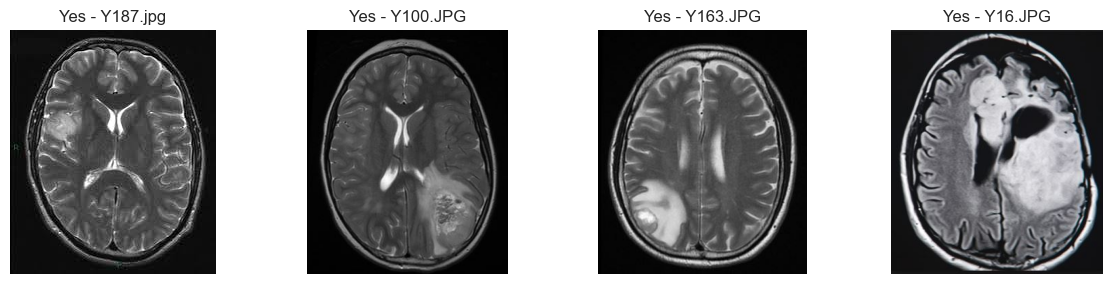

Samples from the 'no' (Healthy) class:


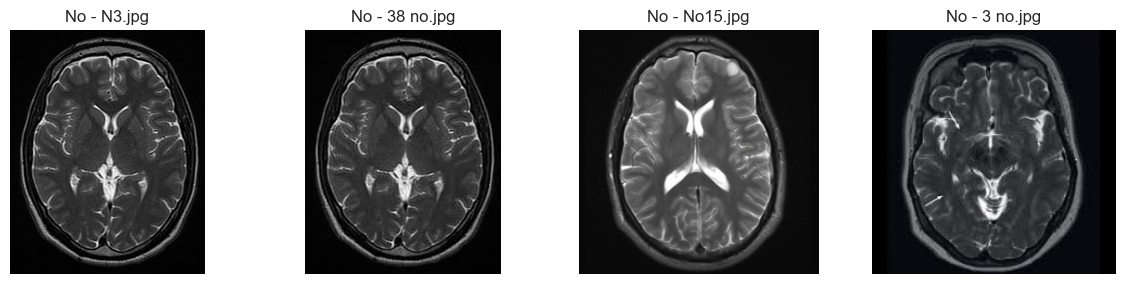

In [11]:
import random

def plot_sample_images(folder_path, label, n=4):
    if not os.path.exists(folder_path):
        return
    files = os.listdir(folder_path)
    sample_files = random.sample(files, min(n, len(files)))
    
    plt.figure(figsize=(12, 3))
    for i, file in enumerate(sample_files):
        img_path = os.path.join(folder_path, file)
        img = Image.open(img_path)
        
        plt.subplot(1, n, i + 1)
        plt.imshow(img, cmap='gray' if img.mode == 'L' else None)
        plt.title(f"{label} - {file}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

if 'yes_path' in locals() and os.path.exists(yes_path):
    print("Samples from the 'yes' (Tumor) class:")
    plot_sample_images(yes_path, "Yes", n=4)

if 'no_path' in locals() and os.path.exists(no_path):
    print("Samples from the 'no' (Healthy) class:")
    plot_sample_images(no_path, "No", n=4)

## 4. Image Dimensions and Formats Analysis
Let's check if images share uniform sizes (resolutions) and examine their color modes (grayscale vs RGB).

In [12]:
def analyze_image_properties(folder_path):
    if not os.path.exists(folder_path):
        return [], [], []
    widths, heights, modes = [], [], []
    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
                modes.append(img.mode)
        except Exception as e:
            print(f"Error with file {file}: {e}")
    return widths, heights, modes

if os.path.exists(yes_path) and os.path.exists(no_path):
    w_yes, h_yes, m_yes = analyze_image_properties(yes_path)
    w_no, h_no, m_no = analyze_image_properties(no_path)

    print(f"YES class - Width min/max: {min(w_yes)} / {max(w_yes)} | Height min/max: {min(h_yes)} / {max(h_yes)}")
    print(f"YES class - Color modes: {set(m_yes)}")
    print(f"NO class  - Width min/max: {min(w_no)} / {max(w_no)} | Height min/max: {min(h_no)} / {max(h_no)}")
    print(f"NO class  - Color modes: {set(m_no)}")
    print("\nConclusion: Images have varying sizes. A resizing step will be required during preprocessing (Notebook 02).")

YES class - Width min/max: 178 / 1275 | Height min/max: 173 / 1427
YES class - Color modes: {'L', 'RGB'}
NO class  - Width min/max: 150 / 1920 | Height min/max: 168 / 1080
NO class  - Color modes: {'P', 'L', 'RGB', 'RGBA'}

Conclusion: Images have varying sizes. A resizing step will be required during preprocessing (Notebook 02).
